# SARIMAX Future Forecasting with T-Bill Data

This notebook fits the **final fixed SARIMAX(2,0,1)** model on the training set and uses a future T-Bill / Treasury path to forecast future mean interest rates.

It keeps the same important transformation from the earlier pipeline:

- **Target**: Box-Cox transform, then second differencing
- **Exogenous series**: log transform of T-Bill / Treasury, then first difference, then lag 1
- **Model**: `SARIMAX(order=(2,0,1))`



## 1. Install and import packages

Run this cell first. It installs any missing packages automatically.

In [1]:


import json
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import inv_boxcox
from scipy.stats import boxcox
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

pd.set_option("display.max_columns", None)

## 2. Set file paths and model settings

Edit these paths before running the notebook.

- `TRAIN_FILE`: training data with `Month`, `int_rate_mean`, and your T-Bill/Treasury column
- `FUTURE_TBILL_FILE`: future dates with the T-Bill/Treasury values you want to feed into the forecast
- if your T-Bill column is not `Treasury_data`, change `TBILL_COL`

In [2]:
TRAIN_FILE = Path("../Data/train.csv")
FUTURE_TBILL_FILE = Path("../Data/tbill.csv")
OUTPUT_DIR = Path("../outputs/sarimax_future")

DATE_COL_TBILL = "observation_date"
DATE_COL_TRAIN = "Month"
TARGET_COL = "int_rate_mean"
TBILL_COL_TBILL = "TB3MS"
TBILL_COL_TRAIN = "Treasury_data"   # change this if needed

tbill_col_used = "Treasury_data"

SARIMAX_ORDER = (2, 0, 1)
TBILL_LAG = 1

## 3. Helper functions

In [21]:

@dataclass(frozen=True)
class TransformState:
    target_boxcox_lambda: float
    target_boxcox_shift: float
    tbill_log_shift: float

def compute_positive_shift(series: pd.Series, buffer: float = 0.0) -> float:
    minimum = float(series.min())
    return max(0.0, -minimum + buffer)

def load_dataset(path: Path, date_col: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if date_col not in df.columns:
        raise ValueError(f"Column '{date_col}' not found in {path}.")
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    return df

def infer_tbill_col(df: pd.DataFrame,  requested_col: str | None) -> str:
    if requested_col not in df.columns:
        raise ValueError(f"Requested TBILL_COL '{requested_col}' is not in the train file.")
        return requested_col



def apply_train_transformations(train_df: pd.DataFrame, date_col: str, target_col: str, tbill_col: str):
    train_ts = train_df[[date_col, target_col, tbill_col]].copy()
    train_ts = train_ts.set_index(date_col).sort_index()

    target_boxcox_shift = compute_positive_shift(train_ts[target_col])
    target_input = train_ts[target_col] + target_boxcox_shift
    train_ts["target_boxcox"], target_boxcox_lambda = boxcox(target_input)
    train_ts["target_diff1"] = train_ts["target_boxcox"].diff(1)
    train_ts["target_diff2"] = train_ts["target_boxcox"].diff(1).diff(1)

    tbill_log_shift = compute_positive_shift(train_ts[tbill_col], buffer=0.1)
    train_ts["tbill_shifted"] = train_ts[tbill_col] + tbill_log_shift
    train_ts["tbill_log"] = np.log(train_ts["tbill_shifted"])
    train_ts["tbill_log_diff"] = train_ts["tbill_log"].diff(1)

    state = TransformState(
        target_boxcox_lambda=float(target_boxcox_lambda),
        target_boxcox_shift=float(target_boxcox_shift),
        tbill_log_shift=float(tbill_log_shift),
    )
    return train_ts, state

def build_train_model_frame(train_ts: pd.DataFrame, tbill_lag: int) -> pd.DataFrame:
    frame = pd.DataFrame(index=train_ts.index)
    frame["target_diff2"] = train_ts["target_diff2"]
    frame["tbill_lag_1"] = train_ts["tbill_log_diff"].shift(tbill_lag)
    frame["prev_diff1"] = train_ts["target_diff1"].shift(1)
    frame["prev_boxcox"] = train_ts["target_boxcox"].shift(1)
    return frame.dropna()

def build_future_exog(train_ts: pd.DataFrame, future_df: pd.DataFrame, date_col: str, tbill_col: str, tbill_lag: int, state: TransformState) -> pd.DataFrame:
    future_ts = future_df[[date_col, tbill_col]].copy().set_index(date_col).sort_index()

    combined_tbill = pd.concat([train_ts[[tbill_col]], future_ts[[tbill_col]]], axis=0)
    combined_tbill["tbill_shifted"] = combined_tbill[tbill_col] + state.tbill_log_shift

    if (combined_tbill["tbill_shifted"] <= 0).any():
        raise ValueError("The training-derived log shift is not sufficient for the provided future T-Bill values.")

    combined_tbill["tbill_log"] = np.log(combined_tbill["tbill_shifted"])
    combined_tbill["tbill_log_diff"] = combined_tbill["tbill_log"].diff(1)
    combined_tbill["tbill_lag_1"] = combined_tbill["tbill_log_diff"].shift(tbill_lag)

    future_exog = combined_tbill.loc[future_ts.index, ["tbill_lag_1"]].copy()
    if future_exog["tbill_lag_1"].isna().any():
        missing_dates = future_exog.index[future_exog["tbill_lag_1"].isna()].strftime("%Y-%m-%d").tolist()
        raise ValueError(
            f"Missing exogenous lag values for future dates: {missing_dates}. "
            "Make sure the future file starts right after the train period or includes enough history."
        )
    return future_exog

def invert_boxcox_value(value: float, state: TransformState) -> float:
    return float(inv_boxcox(value, state.target_boxcox_lambda) - state.target_boxcox_shift)

def reconstruct_recursive_predictions(
    pred_diff2: pd.Series,
    last_train_boxcox: float,
    last_train_diff1: float,
    state: TransformState,
) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    prev_boxcox = float(last_train_boxcox)
    prev_diff1 = float(last_train_diff1)

    for date, diff2_hat in pred_diff2.items():
        diff2_hat = float(diff2_hat)
        boxcox_hat = diff2_hat + prev_diff1 + prev_boxcox
        original_hat = invert_boxcox_value(boxcox_hat, state)
        diff1_hat = boxcox_hat - prev_boxcox

        rows.append(
            {
                "date": date,
                "pred_target_diff2": diff2_hat,
                "pred_target_boxcox": boxcox_hat,
                "pred_target_diff1": diff1_hat,
                "forecast_mean_interest_rate": original_hat,
            }
        )

        prev_boxcox = boxcox_hat
        prev_diff1 = diff1_hat

    return pd.DataFrame(rows)

def fit_model(train_frame: pd.DataFrame, order: tuple[int, int, int]):
    model = SARIMAX(
        endog=train_frame["target_diff2"],
        exog=train_frame[["tbill_lag_1"]],
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fitted = model.fit(disp=False)
    return fitted

def forecast_future(fitted, future_exog: pd.DataFrame) -> pd.Series:
    forecasts = fitted.forecast(steps=len(future_exog), exog=future_exog[["tbill_lag_1"]])
    forecasts.index = future_exog.index
    return forecasts

## 4. Load the train and future T-Bill files

In [22]:
train_df = load_dataset(TRAIN_FILE, DATE_COL_TRAIN)
latest_date = train_df[DATE_COL_TRAIN].max()
future_df = load_dataset(FUTURE_TBILL_FILE, DATE_COL_TBILL)
future_df = future_df[future_df[DATE_COL_TBILL] > latest_date]
future_df = future_df.rename(columns= {TBILL_COL_TBILL : tbill_col_used, DATE_COL_TBILL:DATE_COL_TRAIN})



print("Train shape:", train_df.shape)
print("Future T-Bill shape:", future_df.shape)

display(train_df.head())
display(future_df.head())

Train shape: (104, 9)
Future T-Bill shape: (59, 2)


,Month,int_rate_mean,int_rate_median,int_rate_std,loan_amnt_sum,loan_amnt_mean,loan_amnt_count,Treasury_data,fed_rate
0,2007-06-01,9.814583,9.640,1.886434,91850.0,3827.083333,24,4.61,5.25
1,2007-07-01,11.158571,10.590,2.830279,348325.0,5528.968254,63,4.82,5.26
2,2007-08-01,11.543514,11.065,3.116487,515300.0,6963.513514,74,4.20,5.02
3,2007-09-01,12.463208,11.860,3.157293,372950.0,7036.792453,53,3.89,4.94
4,2007-10-01,12.438476,12.490,2.698128,753225.0,7173.571429,105,3.90,4.76


,Month,Treasury_data
181,2016-02-01,0.31
182,2016-03-01,0.29
183,2016-04-01,0.23
184,2016-05-01,0.27
185,2016-06-01,0.27


## 5. Apply the transformations used by the original workflow

In [23]:
train_ts, state = apply_train_transformations(
    train_df=train_df,
    date_col=DATE_COL,
    target_col=TARGET_COL,
    tbill_col=tbill_col_used,
)

train_frame = build_train_model_frame(train_ts, tbill_lag=TBILL_LAG)

print("Transformed train rows:", len(train_ts))
print("Rows used by SARIMAX after dropping NA from transformations:", len(train_frame))
print("Transform state:", asdict(state))

display(train_ts.head(10))
display(train_frame.head())

Transformed train rows: 104
Rows used by SARIMAX after dropping NA from transformations: 102
Transform state: {'target_boxcox_lambda': -0.17785979805531435, 'target_boxcox_shift': 0.0, 'tbill_log_shift': 0.09000000000000001}


,int_rate_mean,Treasury_data,target_boxcox,target_diff1,target_diff2,tbill_shifted,tbill_log,tbill_log_diff
Month,,,,,,,,
2007-06-01,9.814583,4.61,1.876921,NaN,NaN,4.70,1.547563,NaN
2007-07-01,11.158571,4.82,1.961448,0.084527,NaN,4.91,1.591274,0.043711
2007-08-01,11.543514,4.20,1.983465,0.022017,-0.062510,4.29,1.456287,-0.134987
2007-09-01,12.463208,3.89,2.032743,0.049277,0.027260,3.98,1.381282,-0.075005
2007-10-01,12.438476,3.90,2.031474,-0.001268,-0.050546,3.99,1.383791,0.002509
2007-11-01,11.962321,3.27,2.006458,-0.025016,-0.023748,3.36,1.211941,-0.171850
2007-12-01,11.810523,3.00,1.998235,-0.008223,0.016794,3.09,1.128171,-0.083770
2008-01-01,11.720393,2.75,1.993294,-0.004941,0.003281,2.84,1.043804,-0.084367
2008-02-01,12.195915,2.12,2.018874,0.025580,0.030522,2.21,0.792993,-0.250812


,target_diff2,tbill_lag_1,prev_diff1,prev_boxcox
Month,,,,
2007-08-01,-0.062510,0.043711,0.084527,1.961448
2007-09-01,0.027260,-0.134987,0.022017,1.983465
2007-10-01,-0.050546,-0.075005,0.049277,2.032743
2007-11-01,-0.023748,0.002509,-0.001268,2.031474
2007-12-01,0.016794,-0.171850,-0.025016,2.006458


## 6. Fit the fixed SARIMAX(2,0,1) model on the transformed training data

In [24]:
if train_frame.empty:
    raise ValueError("The transformed training frame is empty. Check that the train data has enough rows.")

fitted = fit_model(train_frame, order=SARIMAX_ORDER)

print("Model order:", SARIMAX_ORDER)
print(fitted.summary())

Model order: (2, 0, 1)
                               SARIMAX Results                                
Dep. Variable:           target_diff2   No. Observations:                  102
Model:               SARIMAX(2, 0, 1)   Log Likelihood                 235.294
Date:                Sun, 15 Mar 2026   AIC                           -460.588
Time:                        10:12:51   BIC                           -447.562
Sample:                    08-01-2007   HQIC                          -455.317
                         - 01-01-2016                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
tbill_lag_1     0.0034      0.009      0.402      0.688      -0.013       0.020
ar.L1          -0.1844      0.365     -0.506      0.613      -0.899       0.531
ar.L2          -0.0482   

c:\Users\sayan\anaconda3new\envs\erdos_summer_2025\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sayan\anaconda3new\envs\erdos_summer_2025\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\sayan\anaconda3new\envs\erdos_summer_2025\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 7. Build the future exogenous series from the provided T-Bill path

Because the model uses **lagged log-differences** of the T-Bill series, the future exogenous values are computed from the **combined train + future** T-Bill data.

In [25]:
future_exog = build_future_exog(
    train_ts=train_ts,
    future_df=future_df,
    date_col=DATE_COL,
    tbill_col=tbill_col_used,
    tbill_lag=TBILL_LAG,
    state=state,
)

display(future_exog.head())
display(future_exog.tail())

,tbill_lag_1
Month,
2016-02-01,0.089612
2016-03-01,0.133531
2016-04-01,-0.051293
2016-05-01,-0.171850
2016-06-01,0.117783


,tbill_lag_1
Month,
2020-08-01,-0.127833
2020-09-01,-0.146603
2020-10-01,0.051293
2020-11-01,-0.051293
2020-12-01,-0.054067


## 8. Forecast recursively into the future

The SARIMAX model forecasts on the transformed target (`target_diff2`).
Then we reconstruct the Box-Cox target and invert back to the original scale.

In [26]:
pred_diff2 = forecast_future(fitted, future_exog)

pred_df = reconstruct_recursive_predictions(
    pred_diff2=pred_diff2,
    last_train_boxcox=float(train_ts["target_boxcox"].iloc[-1]),
    last_train_diff1=float(train_ts["target_diff1"].iloc[-1]),
    state=state,
)

display(pred_df.head())
display(pred_df.tail())

,date,pred_target_diff2,pred_target_boxcox,pred_target_diff1,forecast_mean_interest_rate
0,2016-02-01,0.001078,2.025422,0.001621,12.321268
1,2016-03-01,0.000636,2.027679,0.002257,12.364827
2,2016-04-01,-0.000246,2.029691,0.002011,12.403792
3,2016-05-01,-0.000585,2.031117,0.001426,12.431509
4,2016-06-01,0.000407,2.032949,0.001833,12.467235


,date,pred_target_diff2,pred_target_boxcox,pred_target_diff1,forecast_mean_interest_rate
54,2020-08-01,-0.000438,2.318630,0.000143,19.873721
55,2020-09-01,-0.000503,2.318271,-0.000360,19.861553
56,2020-10-01,0.000176,2.318087,-0.000184,19.855335
57,2020-11-01,-0.000176,2.317727,-0.000360,19.843181
58,2020-12-01,-0.000185,2.317181,-0.000545,19.824780


## 9. Attach actuals if available and compute RMSE / MAE

If your future file includes `int_rate_mean`, this cell will compute forecast errors.
Otherwise it will just keep the forecasts.

In [27]:
has_actuals = TARGET_COL in future_df.columns

pred_df = pred_df.merge(
    future_df[[DATE_COL] + ([TARGET_COL] if has_actuals else [])],
    left_on="date",
    right_on=DATE_COL,
    how="left",
).drop(columns=[DATE_COL])

rmse = None
mae = None

if has_actuals:
    pred_df["actual"] = pred_df[TARGET_COL].astype(float)
    pred_df["abs_error"] = (pred_df["actual"] - pred_df["forecast_mean_interest_rate"]).abs()
    pred_df["squared_error"] = (pred_df["actual"] - pred_df["forecast_mean_interest_rate"]) ** 2
    rmse = float(np.sqrt(mean_squared_error(pred_df["actual"], pred_df["forecast_mean_interest_rate"])))
    mae = float(mean_absolute_error(pred_df["actual"], pred_df["forecast_mean_interest_rate"]))
    print(f"RMSE: {rmse:.6f}")
    print(f"MAE:  {mae:.6f}")
else:
    pred_df["actual"] = np.nan
    pred_df["abs_error"] = np.nan
    pred_df["squared_error"] = np.nan
    print("No actual target column found in the future file, so RMSE and MAE were not computed.")

display(pred_df.head())

No actual target column found in the future file, so RMSE and MAE were not computed.


,date,pred_target_diff2,pred_target_boxcox,pred_target_diff1,forecast_mean_interest_rate,actual,abs_error,squared_error
0,2016-02-01,0.001078,2.025422,0.001621,12.321268,NaN,NaN,NaN
1,2016-03-01,0.000636,2.027679,0.002257,12.364827,NaN,NaN,NaN
2,2016-04-01,-0.000246,2.029691,0.002011,12.403792,NaN,NaN,NaN
3,2016-05-01,-0.000585,2.031117,0.001426,12.431509,NaN,NaN,NaN
4,2016-06-01,0.000407,2.032949,0.001833,12.467235,NaN,NaN,NaN


## 10. Plot the forecast

If actuals are available, this will compare forecast vs actual.

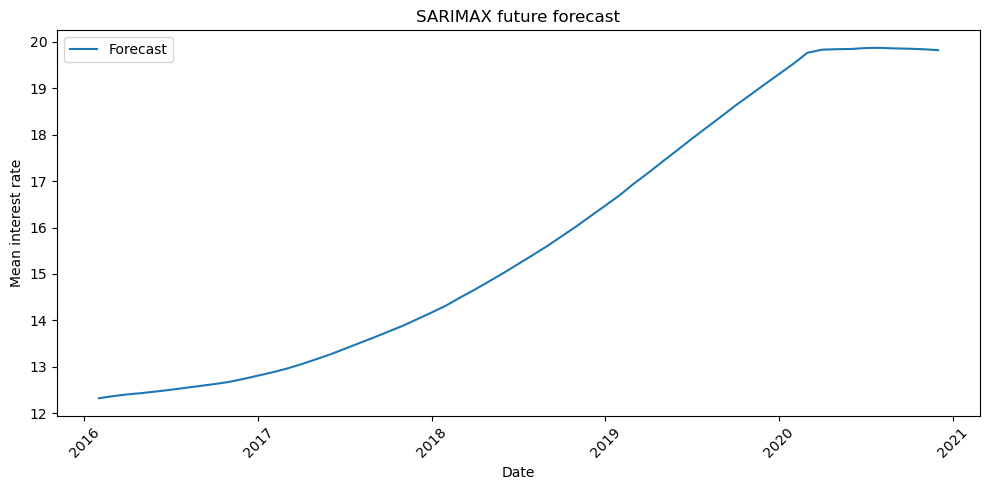

In [28]:
plt.figure(figsize=(10, 5))

plt.plot(pd.to_datetime(pred_df["date"]), pred_df["forecast_mean_interest_rate"], label="Forecast")

if has_actuals:
    plt.plot(pd.to_datetime(pred_df["date"]), pred_df["actual"], label="Actual")

plt.xlabel("Date")
plt.ylabel("Mean interest rate")
plt.title("SARIMAX future forecast")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Inspect errors

This is useful when the future file contains actual values.

In [29]:
if has_actuals:
    error_view = pred_df[["date", "forecast_mean_interest_rate", "actual", "abs_error"]].copy()
    display(error_view.head(20))
else:
    print("No actual values available, so there are no errors to inspect.")

No actual values available, so there are no errors to inspect.


## 12. Save outputs

In [30]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pred_path = OUTPUT_DIR / "sarimax_future_forecasts.csv"
summary_path = OUTPUT_DIR / "sarimax_future_forecast_summary.json"
transform_path = OUTPUT_DIR / "transform_state.json"
params_path = OUTPUT_DIR / "fitted_sarimax_params.json"
model_summary_path = OUTPUT_DIR / "sarimax_model_summary.txt"

pred_to_save = pred_df.copy()
pred_to_save["date"] = pd.to_datetime(pred_to_save["date"]).dt.strftime("%Y-%m-%d")
pred_to_save.to_csv(pred_path, index=False)

summary_payload = {
    "n_train_rows": int(len(train_df)),
    "n_model_rows": int(len(train_frame)),
    "n_future_rows": int(len(future_df)),
    "n_forecasts": int(len(pred_df)),
    "sarimax_order": list(SARIMAX_ORDER),
    "tbill_col": tbill_col_used,
    "rmse": rmse,
    "mae": mae,
}

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2)

with open(transform_path, "w", encoding="utf-8") as f:
    json.dump(asdict(state), f, indent=2)

fitted_params = {str(key): float(value) for key, value in fitted.params.items()}
with open(params_path, "w", encoding="utf-8") as f:
    json.dump(fitted_params, f, indent=2)

with open(model_summary_path, "w", encoding="utf-8") as f:
    f.write(str(fitted.summary()))

print("Saved:")
print(pred_path)
print(summary_path)
print(transform_path)
print(params_path)
print(model_summary_path)

Saved:
outputs\sarimax_future\sarimax_future_forecasts.csv
outputs\sarimax_future\sarimax_future_forecast_summary.json
outputs\sarimax_future\transform_state.json
outputs\sarimax_future\fitted_sarimax_params.json
outputs\sarimax_future\sarimax_model_summary.txt


## 13. Optional: inspect the fitted coefficients directly

In [31]:
pd.DataFrame(
    {
        "parameter": fitted.params.index.astype(str),
        "value": fitted.params.values,
    }
)

,parameter,value
0,tbill_lag_1,0.003430
1,ar.L1,-0.184417
2,ar.L2,-0.048177
3,ma.L1,-2.811034
4,sigma2,0.000063
